In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv
/kaggle/input/datasets/sasivaibhav/dataset1/Sample.csv
/kaggle/input/datasets/sasivaibhav/dataset1/train.csv
/kaggle/input/datasets/sasivaibhav/dataset1/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("/kaggle/input/datasets/sasivaibhav/dataset1/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/sasivaibhav/dataset1/test.csv")
sample_df = pd.read_csv("/kaggle/input/datasets/sasivaibhav/dataset1/Sample.csv")
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


In [3]:
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB
None


In [4]:
train_df.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [5]:
print(train_df.shape)
print(test_df.shape)

(198000, 15)
(102000, 14)


In [6]:
m = train_df.isnull().sum()
print(m.sort_values(ascending=False))


gender          145423
race            145423
religion        145423
comment              1
created_date         0
post_id              0
emoticon_1           0
downvote             0
upvote               0
emoticon_3           0
emoticon_2           0
if_1                 0
if_2                 0
disability           0
label                0
dtype: int64


This observation gives fields with missing values , should be modified using preprocessing methods.


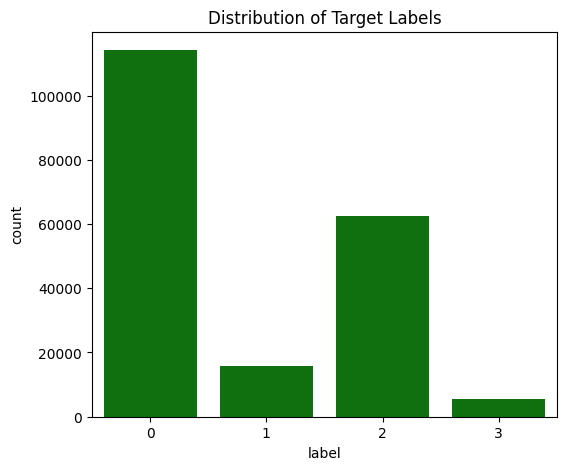

percentages of freq: label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,5))
sns.countplot(x=train_df["label"],color = 'green')
plt.title("Distribution of Target Labels")
plt.show()

print("percentages of freq:",train_df["label"].value_counts(normalize=True))

imbalance seems to be present


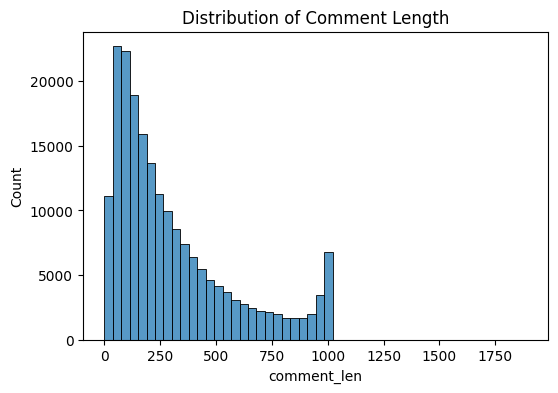

In [8]:
train_df["comment_len"] = train_df["comment"].fillna("").apply(len)
plt.figure(figsize=(6,4))
sns.histplot(train_df["comment_len"], bins=50)
plt.title("Distribution of Comment Length")
plt.show()

left-skewed graph of comment lengths


In [9]:
#pre-processing
train_df["comment"] = train_df["comment"].fillna("")
test_df["comment"] = test_df["comment"].fillna("")

categorical_cols = ["race", "religion", "gender"]

for col in categorical_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna("unknown")
        test_df[col] = test_df[col].fillna("unknown")

In [10]:
train_df["disability"] = train_df["disability"].fillna(False)
test_df["disability"] = test_df["disability"].fillna(False)

Filled missing cat values(NaN) with unknwon constant and boolean missing with false

In [11]:
train_df.head(10)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label,comment_len
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,unknown,unknown,unknown,False,She might be a bright spot for a party keou on...,2,118
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,unknown,unknown,unknown,False,"Under Alaska law, a non-tribal member is not b...",0,644
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,unknown,unknown,unknown,False,in the future please spare me your strawman dr...,2,751
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,unknown,unknown,unknown,False,"PS: That should have been ""rot"" instead of ""co...",2,91
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,unknown,unknown,unknown,False,"Today, the confederate flag...tomorrow, the na...",2,254
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,unknown,unknown,unknown,False,"Hilarious. Since it wasn't Trump, and that yaw...",0,127
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,unknown,unknown,unknown,False,Here's an Idea\nState Owned Foreign Companies ...,0,175
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,unknown,unknown,unknown,False,Victims' participation in the criminla justice...,0,92
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0,171
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,unknown,unknown,unknown,False,I find it remarkbale that this comment is cons...,0,60


all the cat_cols of nan have been changed to unknown


In [12]:
import re
def text_clean(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)   
    text = re.sub(r"[^a-z0-9\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["comment_clean"] = train_df["comment"].apply(text_clean)
test_df["comment_clean"] = test_df["comment"].apply(text_clean)

Remove URLs, HTML tags, and non-alphanumeric characters. Got the text normalized into lowercase.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
text_feature = 'comment'
numerical_features = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2', 'disability']
categorical_features = ['race', 'religion', 'gender']

# TF-IDF Vectorization
text_transformer = TfidfVectorizer(stop_words='english', max_features=10000, ngram_range=(1, 3))

#Scaling
numeric_transformer = StandardScaler()

#One-Hot Encoding
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

#preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer, text_feature),
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

starting most freq dummy model classifier as baseline

In [14]:
#dummy_mcdel classfier (mod1)
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    train_df["comment"],
    train_df["label"],
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)
mod = DummyClassifier(strategy="most_frequent")
mod.fit(X_train, y_train)
val_pred = mod.predict(X_val)
print("acc score:",accuracy_score(y_val,val_pred))

acc score: 0.5766414141414141


In [15]:
#log reg
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', solver='lbfgs'))
])

X = train_df.drop('label', axis=1)
y = train_df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_val)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.66      0.84      0.74      3183
           2       0.88      0.84      0.86     12488
           3       0.42      0.77      0.54      1094

    accuracy                           0.89     39600
   macro avg       0.74      0.85      0.78     39600
weighted avg       0.91      0.89      0.90     39600



In [16]:
print("accuracy:",accuracy_score(y_val,y_pred))

accuracy: 0.8903282828282828


In [17]:
#naive bayes
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# transformer to make all values positive
make_positive = FunctionTransformer(np.abs)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('make_positive', make_positive),
    ('classifier', MultinomialNB())
])

X = train_df.drop('label', axis=1)
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_val)

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.82      0.77     22835
           1       0.34      0.83      0.48      3183
           2       0.80      0.38      0.52     12488
           3       0.67      0.02      0.04      1094

    accuracy                           0.66     39600
   macro avg       0.63      0.51      0.45     39600
weighted avg       0.72      0.66      0.65     39600



performing worse than logistic regression 

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
X = train_df.drop(columns=['label', 'created_date']) 
y = train_df['label']


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model_pipeline,
    X,
    y,          
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std CV:", cv_scores.std())

CV scores: [0.66161616 0.66037879 0.66207071 0.65732323 0.66136364]
Mean CV accuracy: 0.6605505050505049
Std CV: 0.0017060244238467908


The log regression model performs well with accuracy 89 percent and mean cv score to be 88 percent.

<Figure size 640x480 with 0 Axes>

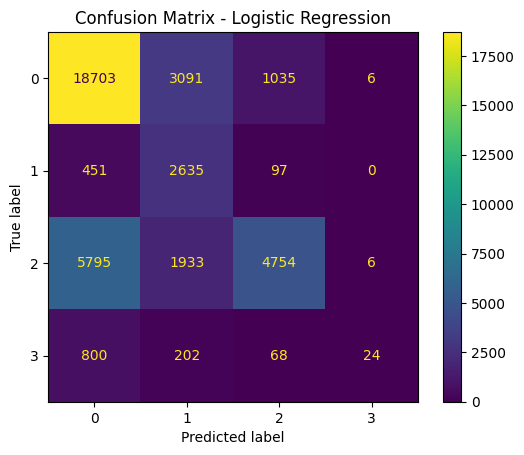

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred)
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [20]:

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']
X_train['comment'] = X_train['comment'].fillna("none")
test_df['comment'] = test_df['comment'].fillna("none")

cat_cols = ['race', 'religion', 'gender']
X_train[cat_cols] = X_train[cat_cols].fillna('none')
test_df[cat_cols] = test_df[cat_cols].fillna('none')
X_train['disability'] = X_train['disability'].astype(int)
test_df['disability'] = test_df['disability'].astype(int)


model_pipeline.fit(X_train, y_train)
pred = model_pipeline.predict(test_df)

submission = sample_df.copy()
submission.iloc[:, 1] = pred 

# 6. Save
submission.to_csv("submission.csv", index=False)
print("Done.")

Done.


trying to implement svm , linearsvc

In [21]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# 1. Separate features and labels
X = train_df.drop(columns=['label', 'created_date'])
y = train_df['label']

X['comment'] = X['comment'].fillna("none")
test_df['comment'] = test_df['comment'].fillna("none")

In [22]:
# Creating the SVC Pipeline
# C=0.1 is used for better generalizatiom
svc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(
        class_weight='balanced', 
        C=0.1, 
        max_iter=2000, 
        dual=False, 
        random_state=42
    ))
])

In [23]:
print("Training Linear SVC")
svc_pipeline.fit(X, y)
print("done")

Training Linear SVC
done


In [24]:
from sklearn.metrics import classification_report

# Predict on validation data
y_pred_svc = svc_pipeline.predict(X_val)

print("Linear SVC Performance:")
print(classification_report(y_val, y_pred_svc))

Linear SVC Performance:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87     22835
           1       0.66      0.83      0.74      3183
           2       0.83      0.70      0.76     12488
           3       0.47      0.78      0.59      1094

    accuracy                           0.81     39600
   macro avg       0.70      0.80      0.74     39600
weighted avg       0.82      0.81      0.82     39600



Improved Precision for Label 3 , The Recall for Label 3 (0.78) and Label 1 (0.83) is good for linearsvc, now as log reg is performing well on accuracy and f1 score ,some kind of ensemble learning can be done.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier

lr_model = LogisticRegression(C=4.0,
    solver="saga",
    n_jobs=-1,
    random_state=42,
    max_iter=2000,
    class_weight="balanced"
)
svc_base = LinearSVC(class_weight='balanced', C=0.1, max_iter=2000, dual=False)
svc_calibrated = CalibratedClassifierCV(svc_base, cv=3)

trying to implement voting first 

In [26]:
ensemble_clf = VotingClassifier(
    estimators=[
        ('lr', lr_model),
        ('svc', svc_calibrated)
    ],
    voting='soft',
    weights=[1.2, 1.0]
)

In [27]:
from sklearn.pipeline import Pipeline

final_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', ensemble_clf)
])

print("Training")
final_model_pipeline.fit(X, y)

Training


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=10000,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  stop_words='english'),
                                                  'comment'),
                                                 ('num', StandardScaler(),
                                                  ['upvote', 'downvote',
                                                   'emoticon_1', 'emoticon_2',
                                                   'emoticon_3', 'if_1', 'if_2',
                                                   'disability']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['race', 'religion',
                                                   'gender'])])),
                ('classifier',
                 VotingClassifier(estimators=[('lr',
                                               LogisticRegression(C=4.0,
                                                                  class_weight='balanced',
                                                                  max_iter=2000,
                                                                  n_jobs=-1,
                                                                  random_state=42,
                                                                  solver='saga')),
                                              ('svc',
                                               CalibratedClassifierCV(cv=3,
                                                                      estimator=LinearSVC(C=0.1,
                                                                                          class_weight='balanced',
                                                                                          dual=False,
                                                                                          max_iter=2000)))],
                                  voting='soft', weights=[1.2, 1.0]))])

In [28]:
from sklearn.metrics import classification_report

y_val_pred = final_model_pipeline.predict(X_val)
print("\nEnsemble Validation Result:")
print(classification_report(y_val, y_val_pred))


Ensemble Validation Result:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94     22835
           1       0.73      0.84      0.78      3183
           2       0.90      0.84      0.87     12488
           3       0.62      0.82      0.70      1094

    accuracy                           0.89     39600
   macro avg       0.79      0.86      0.82     39600
weighted avg       0.90      0.89      0.90     39600



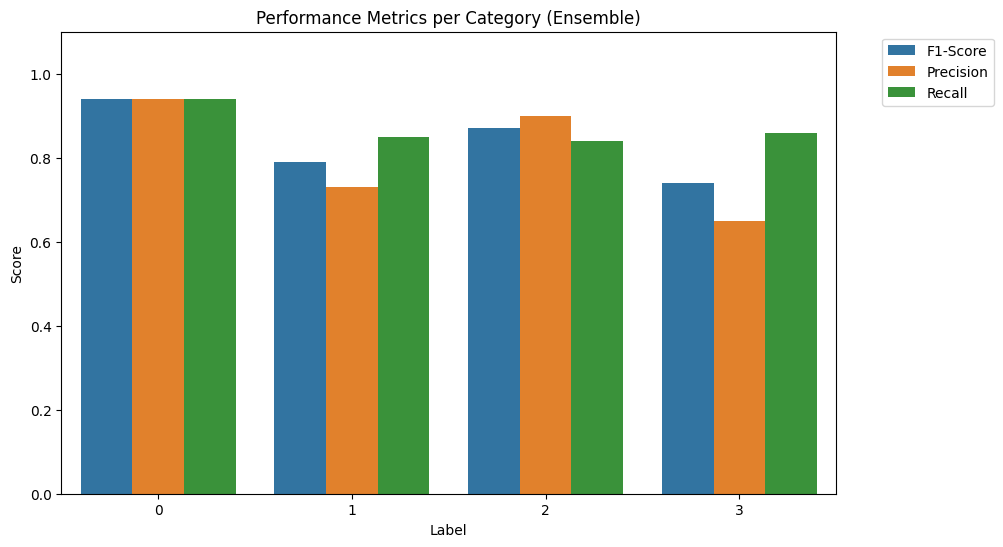

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

metrics = {
    'Label': ['0', '1', '2', '3'],
    'F1-Score': [0.94, 0.79, 0.87, 0.74],
    'Precision': [0.94, 0.73, 0.90, 0.65],
    'Recall': [0.94, 0.85, 0.84, 0.86]
}
df_metrics = pd.DataFrame(metrics).melt(id_vars='Label', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_metrics, x='Label', y='Score', hue='Metric')
plt.title('Performance Metrics per Category (Ensemble)')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

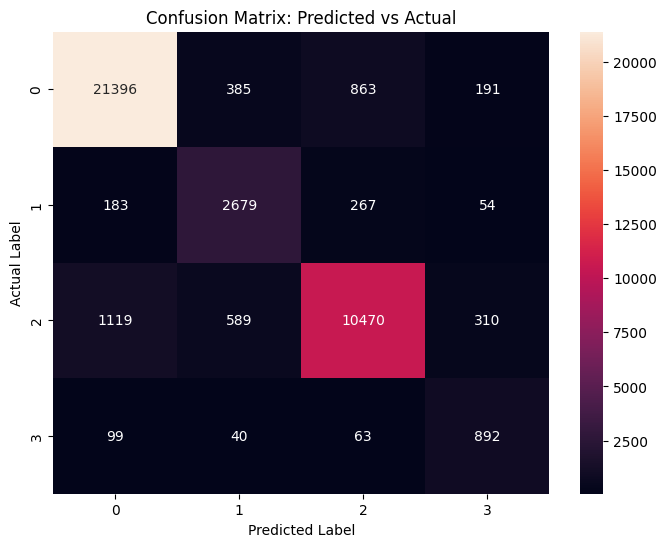

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_val_pred = final_model_pipeline.predict(X_val)
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [31]:
X_train_full = train_df.drop(columns=['label'])
y_train_full = train_df['label']

final_model_pipeline.fit(X_train_full, y_train_full)
pred = final_model_pipeline.predict(test_df)
submission = sample_df.copy()
submission.iloc[:, 1] = pred
submission.to_csv("submission.csv", index=False)
print("done")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


done


trying to implement regex and pandas to extract behavioral signals that are highly correlated with the rare labels (1 and 3)



In [32]:
import re
import pandas as pd
import numpy as np

def enhance_features(df):
    # make a copy so original dataframe is not modified
    df = df.copy()
    # handle missing comments
    df['comment'] = df['comment'].fillna("none")
    df['comment'] = df['comment'].astype(str)
    char_counts = []
    caps_ratios = []
    exclamation_counts = []
    cleaned_comments = []
    for text in df['comment']:
        # character count
        char_counts.append(len(text))
        # uppercase ratio
        upper_chars = sum(1 for c in text if c.isupper())
        caps_ratios.append(upper_chars / (len(text) + 1))
        # number of exclamation marks
        exclamation_counts.append(text.count('!'))
        # remove URLs
        cleaned = re.sub(r'http\S+|www\S+|https\S+', '', text)
        # remove non alphabet characters
        cleaned = re.sub(r'[^a-zA-Z\s]', ' ', cleaned)
        # convert to lowercase
        cleaned = cleaned.lower()
        cleaned_comments.append(cleaned)
    # assign new columns
    df['char_count'] = char_counts
    df['caps_ratio'] = caps_ratios
    df['excl_count'] = exclamation_counts
    df['clean_text'] = cleaned_comments
    return df
train_prepared = enhance_features(train_df)
test_prepared = enhance_features(test_df)

this time ill try to increase max_features to 30,000 and trigram model.

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Columns for the transformer
num_cols = ['upvote', 'downvote', 'if_1', 'if_2', 'char_count', 'caps_ratio', 'excl_count']
cat_cols = ['race', 'religion', 'gender', 'disability']

preprocessor = ColumnTransformer([
    ('text', TfidfVectorizer(max_features=30000, ngram_range=(1, 3), sublinear_tf=True), 'clean_text'),
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

using lightgbm on the ensemble model


In [34]:
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
import lightgbm as lgb

base_learners = [
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', C=4.0,random_state=42,n_jobs=-1,solver="saga")),
    ('svc', CalibratedClassifierCV(LinearSVC(class_weight='balanced', dual=False, C=0.1), cv=3))
]

meta_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight={0:1,1:2,2:1.5,3:3})
stack_ensemble = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    passthrough=True, 
    cv=5,
    n_jobs=-1
)
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', stack_ensemble)
])

In [35]:
X = train_prepared.drop(columns=['label', 'created_date', 'comment'])
y = train_prepared['label']
final_pipeline.fit(X, y)

test_X = test_prepared.drop(columns=['created_date', 'comment'], errors='ignore')
probs = final_pipeline.predict_proba(test_X)
final_preds = []
for p in probs:
    if p[3] > 0.36: 
        final_preds.append(3)
    elif p[1] > 0.38: 
        final_preds.append(1)
    else:
        final_preds.append(np.argmax(p))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 61.683447 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2118756
[LightGBM] [Info] Number of data points in the train set: 198000, number of used features: 30039
[LightGBM] [Info] Start training from score -0.807759
[LightGBM] [Info] Start training from score -2.084877
[LightGBM] [Info] Start training from score -1.005803
[LightGBM] [Info] Start training from score -2.747766


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [36]:
X_val_prepared = enhance_features(X_val)
val_probs = final_pipeline.predict_proba(X_val_prepared)

val_preds = []
for p in val_probs:
    if p[3] > 0.36:
        val_preds.append(3)
    elif p[1] > 0.38:
        val_preds.append(1)
    else:
        val_preds.append(np.argmax(p))

print("class report")
print(classification_report(y_val, val_preds))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


class report
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22835
           1       0.82      0.96      0.89      3183
           2       0.93      0.94      0.93     12488
           3       0.78      0.98      0.87      1094

    accuracy                           0.95     39600
   macro avg       0.88      0.96      0.91     39600
weighted avg       0.95      0.95      0.95     39600



In [37]:
print("Classification Report:")
print(classification_report(y_val, val_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22835
           1       0.82      0.96      0.89      3183
           2       0.93      0.94      0.93     12488
           3       0.78      0.98      0.87      1094

    accuracy                           0.95     39600
   macro avg       0.88      0.96      0.91     39600
weighted avg       0.95      0.95      0.95     39600



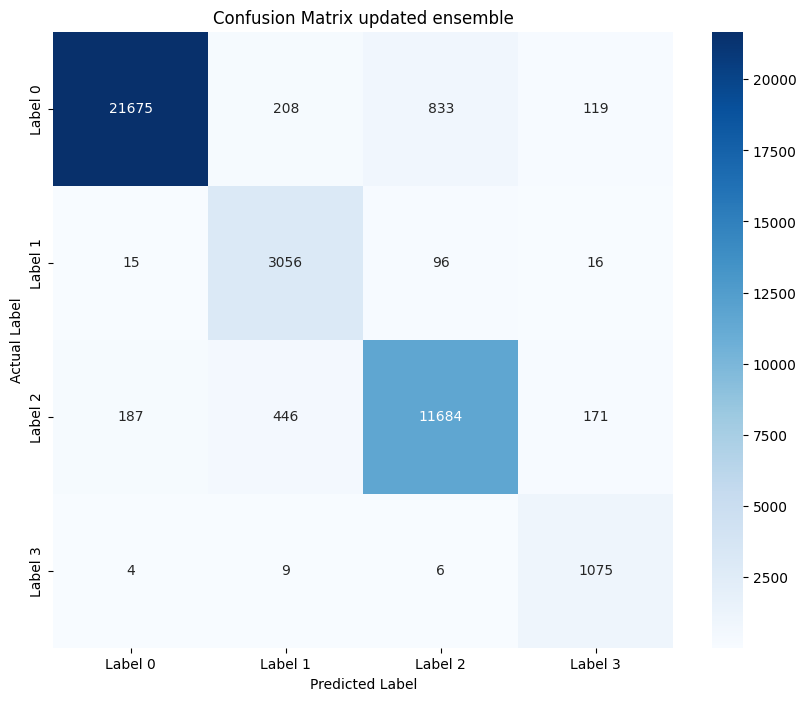

In [38]:
# Plotting the Confusion Matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Label 0', 'Label 1', 'Label 2', 'Label 3'],
            yticklabels=['Label 0', 'Label 1', 'Label 2', 'Label 3'])
plt.title('Confusion Matrix updated ensemble')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

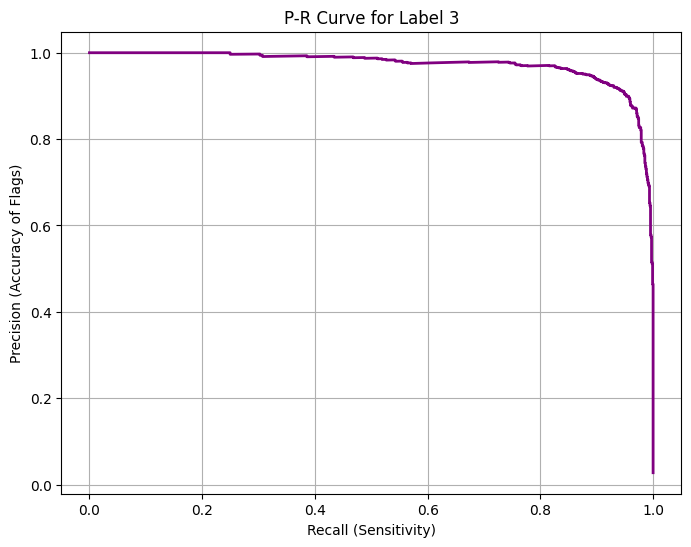

In [39]:
from sklearn.metrics import precision_recall_curve

# Plotting for Label 3 specifically
precision, recall, thresholds = precision_recall_curve(y_val == 3, val_probs[:, 3])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Accuracy of Flags)')
plt.title('P-R Curve for Label 3')
plt.grid(True)
plt.show()

In [40]:
print(pd.Series(final_preds).value_counts(normalize=True))

0    0.552196
2    0.323196
1    0.090804
3    0.033804
Name: proportion, dtype: float64


In [41]:
submission = pd.DataFrame({'ID': sample_df['ID'], 'label': final_preds})
submission.to_csv("submission.csv", index=False)
print("done")

done


using kfold for better thresholds rather than hard thresholding

In [42]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros((len(y), 4))

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    final_pipeline.fit(X_tr, y_tr)

    oof_probs[val_idx] = final_pipeline.predict_proba(X_va)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 52.906149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1800058
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30039
[LightGBM] [Info] Start training from score -0.807770
[LightGBM] [Info] Start training from score -2.084914
[LightGBM] [Info] Start training from score -1.005809
[LightGBM] [Info] Start training from score -2.747589


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 54.751909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1798840
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30039
[LightGBM] [Info] Start training from score -0.807765
[LightGBM] [Info] Start training from score -2.084830
[LightGBM] [Info] Start training from score -1.005804
[LightGBM] [Info] Start training from score -2.747813


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 49.227093 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1801499
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30039
[LightGBM] [Info] Start training from score -0.807749
[LightGBM] [Info] Start training from score -2.084904
[LightGBM] [Info] Start training from score -1.005799
[LightGBM] [Info] Start training from score -2.747808


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 49.085465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1802401
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 30039
[LightGBM] [Info] Start training from score -0.807749
[LightGBM] [Info] Start training from score -2.084904
[LightGBM] [Info] Start training from score -1.005799
[LightGBM] [Info] Start training from score -2.747808


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
from sklearn.metrics import f1_score

best_score = 0
best_t1, best_t3 = 0, 0

for t3 in np.arange(0.30,0.42,0.01):
    for t1 in np.arange(0.35, 0.48, 0.01):

        preds = []

        for p in oof_probs:
            if p[3] > t3:
                preds.append(3)
            elif p[1] > t1:
                preds.append(1)
            else:
                preds.append(np.argmax(p))

        score = f1_score(y, preds, average="macro")

        if score > best_score:
            best_score = score
            best_t1, best_t3 = t1, t3

print(best_score, best_t1, best_t3)

0.8232364263517365 0.4700000000000001 0.4100000000000001


In [44]:
test_probs = final_pipeline.predict_proba(test_X)

final_preds = []

for p in test_probs:
    if p[3] > best_t3:
        final_preds.append(3)
    elif p[1] > best_t1:
        final_preds.append(1)
    else:
        final_preds.append(np.argmax(p))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [45]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import numpy as np

# Predict probabilities
val_probs = final_pipeline.predict_proba(X_val_prepared)

# Apply tuned thresholds
val_preds = []
for p in val_probs:
    if p[3] > best_t3:
        val_preds.append(3)
    elif p[1] > best_t1:
        val_preds.append(1)
    else:
        val_preds.append(np.argmax(p))

val_preds = np.array(val_preds)

# Classification report
print("Classification Report:\n")
print(classification_report(y_val, val_preds))

# Macro F1
macro_f1 = f1_score(y_val, val_preds, average="macro")
print("\nMacro F1 Score:", macro_f1)

# Accuracy
accuracy = accuracy_score(y_val, val_preds)
print("Accuracy:", accuracy)

# Confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_val, val_preds))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     22835
           1       0.85      0.93      0.89      3183
           2       0.92      0.95      0.93     12488
           3       0.79      0.94      0.86      1094

    accuracy                           0.95     39600
   macro avg       0.88      0.94      0.91     39600
weighted avg       0.95      0.95      0.95     39600


Macro F1 Score: 0.9104281225443507
Accuracy: 0.9464393939393939

Confusion Matrix:

[[21682   194   860    99]
 [   24  2959   174    26]
 [  190   333 11810   155]
 [    6    12    48  1028]]


In [46]:
# Create submission dataframe
submission = pd.DataFrame({
    'ID': sample_df['ID'],
    'label': final_preds
})

# Save submission file
submission.to_csv("submission.csv", index=False)

print("Done")

Done


In [47]:
print(pd.Series(final_preds).value_counts())

0    56368
2    33608
1     8753
3     3271
Name: count, dtype: int64


In [48]:
print(submission.head(10))
print(submission.shape)

   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
5   6      0
6   7      1
7   8      0
8   9      0
9  10      2
(102000, 2)
